<div style="background:linear-gradient(90deg,#2d1b14,#4e7d2a);padding:38px 18px;margin:18px 0 12px 0;border-radius:18px;border:3px solid #d4a843;text-align:center;">
  <h1 style="color:#fff1b4;font-family:Arial,sans-serif;font-size:34px;font-weight:800;margin:0;line-height:1.15;">Crustle Wall Submission Notebook</h1>
</div>

| Artifact | Output |
|---|---|
| `deck.csv` | 60-card list copied from the top Crustle package |
| `main.py` | submit-ready rule-based agent |
| `submission.tar.gz` | upload bundle |
| `cg/` | competition engine copied from Kaggle input |

## Deck snapshot

This notebook is locked to the top Crustle wall package. The policy below is tuned for the mirror-relevant details: keep a fresh Crustle with Cape or Counter Gain online, do not waste extra energy on one wall past three attachments, and send overflow energy to the next attacker.

In [1]:
from pathlib import Path

HARD_CODED_DECK = [
    345, 345, 345, 345,
    344, 344, 344, 344,
    979,
    117,
    378,
    112, 112,
    1182, 1182, 1182, 1182,
    1227, 1227, 1227,
    1219, 1219, 1219, 1219,
    1198, 1198, 1198, 1198,
    1197,
    1225,
    1122, 1122, 1122, 1122,
    1152, 1152,
    1086, 1086,
    1121, 1121,
    1097, 1097,
    1147, 1147,
    1174,
    1159,
    1168,
    1175,
    11, 11, 11,
    1, 1, 1, 1,
    7, 7, 7,
    6, 6,
]

assert len(HARD_CODED_DECK) == 60
Path('deck.csv').write_text('\n'.join(map(str, HARD_CODED_DECK)) + '\n', encoding='utf-8')
print('deck.csv written')
print('cards:', len(HARD_CODED_DECK))


deck.csv written
cards: 60


,card_id,card_name,role,count
0,345,Crustle,wall,4
1,344,Dwebble,setup,4
2,1219,Team Rocket's Petrel,support,4
3,1198,Crispin,support,4
4,1182,#1182,other,4
5,1122,Pok?gear 3.0,search,4
6,1,Basic Grass Energy,energy,4
7,11,Mist Energy,energy,3
8,7,Basic Darkness Energy,energy,3
9,1227,Lillie's Determination,support,3


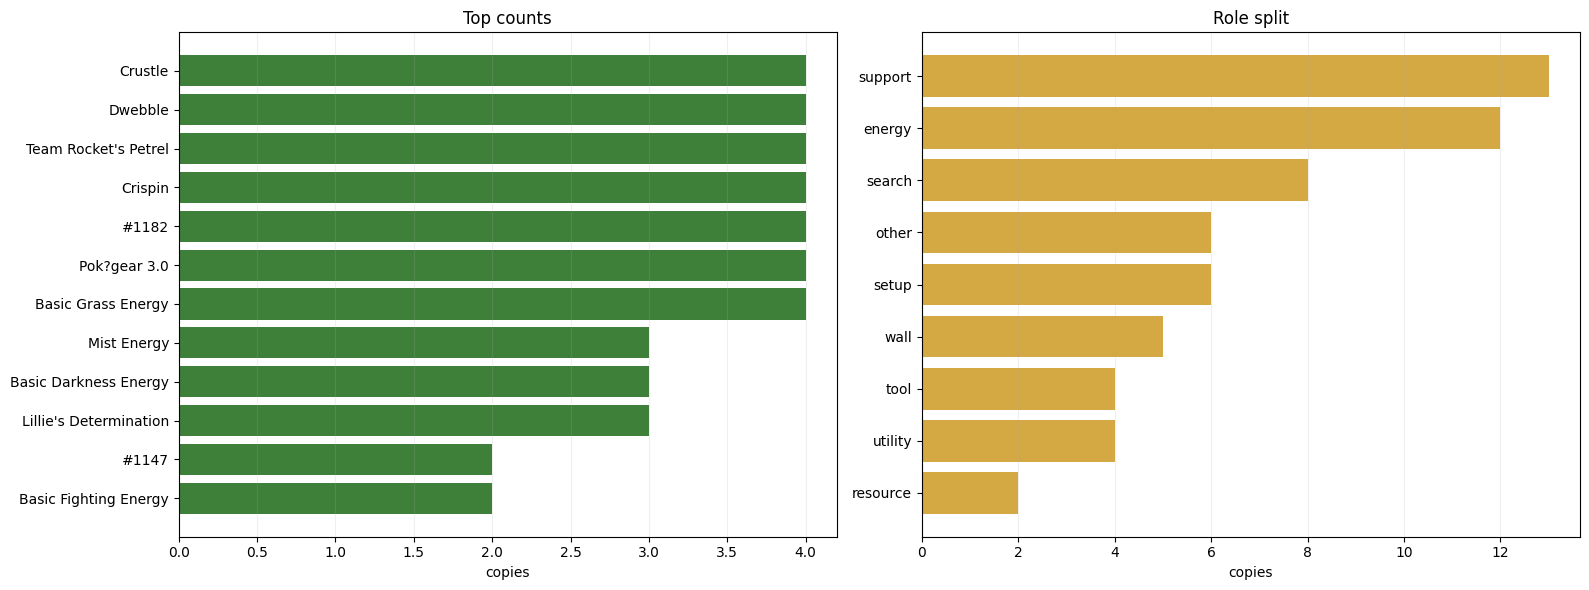

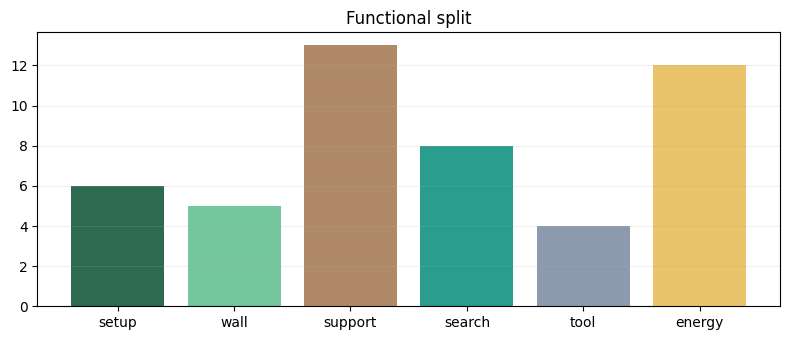

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

CARD_NAMES = {
    1: 'Basic Grass Energy',
    6: 'Basic Fighting Energy',
    7: 'Basic Darkness Energy',
    11: 'Mist Energy',
    112: 'Munkidori',
    117: 'Cornerstone Mask Ogerpon ex',
    344: 'Dwebble',
    345: 'Crustle',
    378: "Ethan's Sudowoodo",
    979: 'Koraidon ex',
    1086: 'Buddy-Buddy Poffin',
    1097: 'Night Stretcher',
    1121: 'Ultra Ball',
    1122: 'Pok?gear 3.0',
    1152: 'Pok? Pad',
    1159: "Hero's Cape",
    1168: 'Counter Gain',
    1174: 'Air Balloon',
    1175: 'Brave Bangle',
    1197: "Xerosic's Machinations",
    1198: 'Crispin',
    1219: "Team Rocket's Petrel",
    1225: 'Hilda',
    1227: "Lillie's Determination",
}
ROLE = {
    1: 'energy', 6: 'energy', 7: 'energy', 11: 'energy',
    344: 'setup', 345: 'wall', 378: 'utility', 112: 'utility', 117: 'wall', 979: 'utility',
    1086: 'setup', 1097: 'resource', 1121: 'search', 1122: 'search', 1152: 'search',
    1159: 'tool', 1168: 'tool', 1174: 'tool', 1175: 'tool',
    1197: 'support', 1198: 'support', 1219: 'support', 1225: 'support', 1227: 'support',
}

deck_ids = [int(x) for x in Path('deck.csv').read_text(encoding='utf-8').splitlines() if x.strip()]
counts = pd.Series(deck_ids).value_counts().sort_values(ascending=False)
deck_df = pd.DataFrame([
    {
        'card_id': cid,
        'card_name': CARD_NAMES.get(cid, f'#{cid}'),
        'role': ROLE.get(cid, 'other'),
        'count': int(count),
    }
    for cid, count in counts.items()
])
display(deck_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_df = deck_df.head(12).iloc[::-1]
axes[0].barh(plot_df['card_name'], plot_df['count'], color='#3e7f3a')
axes[0].set_title('Top counts')
axes[0].set_xlabel('copies')
axes[0].grid(axis='x', alpha=0.2)
role_counts = deck_df.groupby('role')['count'].sum().sort_values(ascending=True)
axes[1].barh(role_counts.index, role_counts.values, color='#d4a843')
axes[1].set_title('Role split')
axes[1].set_xlabel('copies')
axes[1].grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(['setup', 'wall', 'support', 'search', 'tool', 'energy'], [
    int(role_counts.get('setup', 0)),
    int(role_counts.get('wall', 0)),
    int(role_counts.get('support', 0)),
    int(role_counts.get('search', 0)),
    int(role_counts.get('tool', 0)),
    int(role_counts.get('energy', 0)),
], color=['#2d6a4f', '#74c69d', '#b08968', '#2a9d8f', '#8d99ae', '#e9c46a'])
ax.set_title('Functional split')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [3]:
%%writefile main.py
import os
from collections import Counter, defaultdict

from cg.api import (
    AreaType,
    CardType,
    EnergyType,
    OptionType,
    SelectContext,
    Pokemon,
    Card,
    all_attack,
    all_card_data,
    to_observation_class,
)


# ============================================================================
# Deck: top Crustle package adapted to the competition card IDs
# ============================================================================
MY_DECK = [
    345, 345, 345, 345,  # Crustle
    344, 344, 344, 344,  # Dwebble
    979,                 # Koraidon ex
    117,                 # Cornerstone Mask Ogerpon ex
    378,                 # Ethan's Sudowoodo
    112, 112,            # Munkidori
    1182, 1182, 1182, 1182,  # Boss's Orders
    1227, 1227, 1227,        # Lillie's Determination
    1219, 1219, 1219, 1219,  # Team Rocket's Petrel
    1198, 1198, 1198, 1198,  # Crispin
    1197,                    # Xerosic's Machinations
    1225,                    # Hilda
    1122, 1122, 1122, 1122,  # Pokégear 3.0
    1152, 1152,              # Poké Pad
    1086, 1086,              # Buddy-Buddy Poffin
    1121, 1121,              # Ultra Ball
    1097, 1097,              # Night Stretcher
    1147, 1147,              # Jumbo Ice Cream
    1174,                    # Air Balloon
    1159,                    # Hero's Cape
    1168,                    # Counter Gain
    1175,                    # Brave Bangle
    11, 11, 11,              # Mist Energy
    1, 1, 1, 1,              # Basic Grass Energy
    7, 7, 7,                 # Basic Darkness Energy
    6, 6,                    # Basic Fighting Energy
]

assert len(MY_DECK) == 60


# ============================================================================
# Engine data
# ============================================================================
try:
    ALL_CARD = all_card_data()
    CARD_TABLE = {c.cardId: c for c in ALL_CARD}
except Exception:
    ALL_CARD = []
    CARD_TABLE = {}

try:
    ALL_ATTACK = all_attack()
    ATTACK_TABLE = {a.attackId: a for a in ALL_ATTACK}
except Exception:
    ALL_ATTACK = []
    ATTACK_TABLE = {}


# ============================================================================
# Card IDs
# ============================================================================
C = {
    "DWEBBLE": 344,
    "CRUSTLE": 345,
    "KORAIDON_EX": 979,
    "CORNERSTONE_EX": 117,
    "SUDOWOODO": 378,
    "MUNKIDORI": 112,
    "BOSS": 1182,
    "LILLIE": 1227,
    "PETREL": 1219,
    "CRISPIN": 1198,
    "XEROSIC": 1197,
    "HILDA": 1225,
    "POKEGEAR": 1122,
    "POKE_PAD": 1152,
    "POFFIN": 1086,
    "ULTRA_BALL": 1121,
    "NIGHT_STRETCHER": 1097,
    "JUMBO_ICECREAM": 1147,
    "AIR_BALLOON": 1174,
    "HERO_CAPE": 1159,
    "COUNTER_GAIN": 1168,
    "BRAVE_BANGLE": 1175,
    "MIST_ENERGY": 11,
    "BASIC_GRASS": 1,
    "BASIC_DARKNESS": 7,
    "BASIC_FIGHTING": 6,
}

CRUSTLE_ATTACK = 479
KORAIDON_ATTACK = 1409
KORAIDON_BENCH_EFFECT = 1408
OGERPON_ATTACK = 148
MUNKIDORI_ATTACK = 141
SUDOWOODO_ATTACK = 527
SUDOWOODO_COPY = 528

LOW_DECK_THRESHOLD = 8


class AttackPlan:
    attacker = 0
    target = 0
    attack_id = 0
    needs_switch = False
    needs_energy = False
    score = -10**9


plan = AttackPlan()
pre_turn = -1


def get_card(obs, area, index, player_index):
    try:
        ps = obs.current.players[player_index]
        if area == AreaType.DECK:
            return obs.select.deck[index]
        if area == AreaType.HAND:
            return ps.hand[index]
        if area == AreaType.DISCARD:
            return ps.discard[index]
        if area == AreaType.ACTIVE:
            return ps.active[index]
        if area == AreaType.BENCH:
            return ps.bench[index]
        if area == AreaType.PRIZE:
            return ps.prize[index]
        if area == AreaType.STADIUM:
            return obs.current.stadium[index]
        if area == AreaType.LOOKING:
            return obs.current.looking[index]
    except Exception:
        return None
    return None


def board_cards(state, player_index):
    player = state.players[player_index]
    active = [player.active[0]] if player.active else []
    return [c for c in active + list(player.bench) if c is not None]


def count_ids(cards):
    counter = Counter()
    for c in cards:
        if c is not None:
            counter[c.id] += 1
    return counter


def prize_count(card):
    data = CARD_TABLE.get(card.id)
    if data is None:
        return 1
    if data.megaEx:
        return 3
    if data.ex:
        return 2
    return 1


def energy_counter(pokemon):
    return Counter(int(e) for e in getattr(pokemon, "energies", []))


def energy_value_for_target(card_id):
    if card_id == C["BASIC_GRASS"]:
        return 300
    if card_id == C["MIST_ENERGY"]:
        return 240
    if card_id == C["BASIC_DARKNESS"]:
        return 220
    if card_id == C["BASIC_FIGHTING"]:
        return 210
    return 100


def needs_grass_line(pokemon):
    ec = energy_counter(pokemon)
    return ec[int(EnergyType.GRASS)] == 0


def has_attack_cost(pokemon, attack_id, has_counter_gain=False):
    attack = ATTACK_TABLE.get(attack_id)
    if attack is None:
        return False
    ec = energy_counter(pokemon)
    counts = Counter(attack.energies)
    colorless_needed = counts[int(EnergyType.COLORLESS)]
    if has_counter_gain and colorless_needed > 0:
        colorless_needed -= 1
    for etype, need in counts.items():
        if etype == int(EnergyType.COLORLESS):
            continue
        if ec[etype] < need:
            return False
    return sum(ec.values()) >= sum(counts.values()) - (1 if has_counter_gain and counts[int(EnergyType.COLORLESS)] else 0)


def damage_value_against(card, damage):
    data = CARD_TABLE.get(card.id)
    if data is None:
        return damage
    if data.weakness == EnergyType.GRASS:
        damage *= 2
    elif data.resistance == EnergyType.GRASS:
        damage -= 30
    return max(0, damage)


def target_score(card, damage):
    data = CARD_TABLE.get(card.id)
    if data is None:
        return 0
    prizes = prize_count(card)
    if card.hp <= damage:
        score = prizes * 2500 + 2000
    else:
        score = prizes * 1200 + int(damage * 12 / max(1, card.hp))
    score += len(getattr(card, "energies", [])) * 110
    score += len(getattr(card, "tools", [])) * 120
    if data.stage1:
        score += 120
    if data.stage2:
        score += 240
    if data.ex:
        score += 350
    if card.id in {C["CORNERSTONE_EX"], C["KORAIDON_EX"]}:
        score += 120
    return score


def my_energy_state(pokemon):
    ec = energy_counter(pokemon)
    return {
        "grass": ec[int(EnergyType.GRASS)],
        "dark": ec[int(EnergyType.DARKNESS)],
        "fight": ec[int(EnergyType.FIGHTING)],
        "misc": ec[int(EnergyType.COLORLESS)],
        "total": sum(ec.values()),
    }


def crustle_ready(pokemon):
    e = my_energy_state(pokemon)
    if e["grass"] == 0:
        return False
    return e["misc"] + e["grass"] >= 3 or e["misc"] + e["grass"] >= 2 and has_counter_gain_attached(pokemon)


def has_counter_gain_attached(pokemon):
    return any(tool.id == C["COUNTER_GAIN"] for tool in getattr(pokemon, "tools", []))


def board_index_to_pokemon(state, player_index, board_index):
    player = state.players[player_index]
    if board_index == 0:
        return player.active[0] if player.active else None
    if 1 <= board_index <= len(player.bench):
        return player.bench[board_index - 1]
    return None


def attack_plan(obs):
    state = obs.current
    me = state.players[state.yourIndex]
    opp = state.players[1 - state.yourIndex]
    my_board = board_cards(state, state.yourIndex)
    opp_board = board_cards(state, 1 - state.yourIndex)
    my_counts = count_ids(my_board)
    opp_counts = count_ids(opp_board)
    can_gust = any(o.type == OptionType.PLAY and get_card(obs, AreaType.HAND, o.index, state.yourIndex) is not None and get_card(obs, AreaType.HAND, o.index, state.yourIndex).id == C["BOSS"] for o in obs.select.option)

    best = AttackPlan()
    for ai, attacker in enumerate(my_board):
        if attacker is None:
            continue
        if ai != 0 and not any(o.type == OptionType.RETREAT for o in obs.select.option):
            continue

        a_data = CARD_TABLE.get(attacker.id)
        if a_data is None:
            continue
        has_gain = has_counter_gain_attached(attacker) and me.prize and len(me.prize) > len(opp.prize)

        for attack_id in a_data.attacks:
            atk = ATTACK_TABLE.get(attack_id)
            if atk is None:
                continue
            if not has_attack_cost(attacker, attack_id, has_gain):
                continue

            atk_score = 0
            if attack_id == CRUSTLE_ATTACK:
                atk_score = 1000
                if ai == 0:
                    atk_score += 80
            elif attack_id == OGERPON_ATTACK:
                atk_score = 920
            elif attack_id == KORAIDON_ATTACK:
                atk_score = 860
            elif attack_id == SUDOWOODO_ATTACK:
                atk_score = 650
            elif attack_id == MUNKIDORI_ATTACK:
                atk_score = 500
            elif attack_id == SUDOWOODO_COPY:
                atk_score = 520

            if attacker.id == C["CRUSTLE"]:
                atk_score += 250
            elif attacker.id == C["CORNERSTONE_EX"]:
                atk_score += 130
            elif attacker.id == C["KORAIDON_EX"]:
                atk_score += 90
            elif attacker.id == C["MUNKIDORI"]:
                atk_score += 60

            damage = atk.damage
            if attacker.id == C["CRUSTLE"]:
                damage += 30 if any(tool.id == C["BRAVE_BANGLE"] for tool in getattr(attacker, "tools", [])) else 0
                if ai == 0 and attacker.hp < attacker.maxHp:
                    damage += 20

            target_indices = [0]
            if can_gust:
                target_indices = list(range(len(opp_board)))

            for ti in target_indices:
                target = opp_board[ti]
                if target is None:
                    continue
                tdmg = damage_value_against(target, damage)
                score = atk_score + target_score(target, tdmg)
                if ti == 0:
                    score += 400
                if tdmg >= target.hp:
                    score += prize_count(target) * 700
                if attacker.id == C["CRUSTLE"]:
                    if target.id in {C["KORAIDON_EX"], C["CORNERSTONE_EX"]}:
                        score += 160
                    if target.id == C["CRUSTLE"]:
                        score += 220
                if attacker.id == C["CORNERSTONE_EX"] and target.id == C["CRUSTLE"]:
                    score += 90
                if attacker.id == C["KORAIDON_EX"] and target.id == C["CRUSTLE"]:
                    score += 70
                if score > best.score:
                    best.score = score
                    best.attacker = ai
                    best.target = ti
                    best.attack_id = attack_id
                    best.needs_switch = ai != 0
                    best.needs_energy = False
    return best


def play_target_priority(card, state, my_index):
    my_state = state.players[my_index]
    counts = count_ids(board_cards(state, my_index))
    if card.id == C["DWEBBLE"]:
        return 9000 if counts[C["CRUSTLE"]] < 4 else 8000
    if card.id == C["CRUSTLE"]:
        if counts[C["DWEBBLE"]] > counts[C["CRUSTLE"]]:
            return 9500
        return 8600
    if card.id == C["MUNKIDORI"]:
        return 8200
    if card.id == C["KORAIDON_EX"]:
        return 7400
    if card.id == C["CORNERSTONE_EX"]:
        return 7300
    if card.id == C["SUDOWOODO"]:
        return 7100
    if card.id == C["BOSS"]:
        return 5600
    if card.id == C["CRISPIN"]:
        return 9800
    if card.id == C["HILDA"]:
        return 9700
    if card.id == C["PETREL"]:
        return 9200
    if card.id == C["XEROSIC"]:
        return 4300
    if card.id == C["LILLIE"]:
        return 8800
    if card.id == C["POKEGEAR"]:
        return 9300
    if card.id == C["POKE_PAD"]:
        return 9100
    if card.id == C["POFFIN"]:
        return 9400
    if card.id == C["ULTRA_BALL"]:
        return 9600
    if card.id == C["NIGHT_STRETCHER"]:
        return 7800
    if card.id == C["JUMBO_ICECREAM"]:
        return 5200
    if card.id == C["AIR_BALLOON"]:
        return 4800
    if card.id == C["HERO_CAPE"]:
        return 8700
    if card.id == C["COUNTER_GAIN"]:
        return 8600
    if card.id == C["BRAVE_BANGLE"]:
        return 8500
    return 1000


def pokemon_to_hand_score(card, state, my_index):
    counts = count_ids(board_cards(state, my_index))
    if card.id == C["DWEBBLE"]:
        return 12000 if counts[C["DWEBBLE"]] < 4 else 9000
    if card.id == C["CRUSTLE"]:
        return 13000 if counts[C["DWEBBLE"]] > counts[C["CRUSTLE"]] else 11000
    if card.id == C["MUNKIDORI"]:
        return 10800
    if card.id == C["KORAIDON_EX"]:
        return 9800
    if card.id == C["CORNERSTONE_EX"]:
        return 9600
    if card.id == C["SUDOWOODO"]:
        return 9000
    return 1000


def target_play_score(card, state, my_index):
    counts = count_ids(board_cards(state, my_index))
    if card.id == C["DWEBBLE"]:
        return 10000 if counts[C["DWEBBLE"]] < 4 else 8500
    if card.id == C["CRUSTLE"]:
        return 12500 if counts[C["DWEBBLE"]] > counts[C["CRUSTLE"]] else 10500
    if card.id == C["MUNKIDORI"]:
        return 11500
    if card.id == C["KORAIDON_EX"]:
        return 9300
    if card.id == C["CORNERSTONE_EX"]:
        return 9200
    if card.id == C["SUDOWOODO"]:
        return 9000
    return 500


def low_deck(state, my_index):
    return state.players[my_index].deckCount <= LOW_DECK_THRESHOLD


def supporter_score(card, state, my_index, hand_counts, board_counts):
    if card.id == C["CRISPIN"]:
        need_grass = board_counts[C["CRUSTLE"]] > 0 and not any(
            p and p.id == C["CRUSTLE"] and energy_counter(p)[int(EnergyType.GRASS)] > 0
            for p in board_cards(state, my_index)
        )
        if low_deck(state, my_index):
            return 1500
        return 14000 if need_grass else 11000
    if card.id == C["HILDA"]:
        return 13800 if not low_deck(state, my_index) else 7000
    if card.id == C["PETREL"]:
        return 12600 if hand_counts[C["BOSS"]] == 0 and not low_deck(state, my_index) else 7000
    if card.id == C["LILLIE"]:
        return 10500 if not low_deck(state, my_index) else 6000
    if card.id == C["XEROSIC"]:
        opp_hand = state.players[1 - my_index].handCount
        return 11800 if opp_hand > 4 and not low_deck(state, my_index) else 5200
    if card.id == C["BOSS"]:
        return 11200 if not low_deck(state, my_index) else 3000
    return 7000


def item_score(card, state, my_index, hand_counts, board_counts):
    if card.id == C["POFFIN"]:
        need_dwebble = board_counts[C["DWEBBLE"]] < 4
        need_munki = board_counts[C["MUNKIDORI"]] < 2
        return 14500 if (need_dwebble or need_munki) and not low_deck(state, my_index) else 3500
    if card.id == C["ULTRA_BALL"]:
        return 13200 if not low_deck(state, my_index) else 5000
    if card.id == C["POKEGEAR"]:
        return 12600 if not low_deck(state, my_index) else 5000
    if card.id == C["POKE_PAD"]:
        return 12300 if not low_deck(state, my_index) else 5000
    if card.id == C["NIGHT_STRETCHER"]:
        return 11100 if not low_deck(state, my_index) else 4500
    if card.id == C["JUMBO_ICECREAM"]:
        return 7600 if not low_deck(state, my_index) else 3000
    if card.id == C["HERO_CAPE"]:
        return 11600
    if card.id == C["COUNTER_GAIN"]:
        return 11800
    if card.id == C["BRAVE_BANGLE"]:
        return 11400
    if card.id == C["AIR_BALLOON"]:
        return 5000
    return 4000


def choose_energy_target(card, pokemon, state, my_index):
    e = my_energy_state(pokemon)
    tool_ids = {tool.id for tool in getattr(pokemon, "tools", [])}
    behind = len(state.players[my_index].prize) > len(state.players[1 - my_index].prize)

    if card.id == C["MIST_ENERGY"]:
        if pokemon.id == C["CRUSTLE"]:
            score = 9000
            if e["grass"] == 0:
                score += 3000
            if e["misc"] < 2:
                score += 1600
            if behind and C["COUNTER_GAIN"] in tool_ids and e["grass"] >= 1 and e["misc"] >= 1:
                score += 2000
            if e["total"] >= 3:
                score -= 5000
            return score
        if pokemon.id in {C["KORAIDON_EX"], C["CORNERSTONE_EX"], C["MUNKIDORI"], C["SUDOWOODO"]}:
            return 5000
        return 1000
    if card.id == C["BASIC_GRASS"]:
        if pokemon.id == C["CRUSTLE"]:
            score = 10000
            if e["grass"] == 0:
                score += 5000
            if e["total"] >= 3:
                score -= 4000
            return score
        if pokemon.id == C["CORNERSTONE_EX"]:
            return 7000
        return 2500
    if card.id == C["BASIC_DARKNESS"]:
        if pokemon.id == C["MUNKIDORI"]:
            return 9200 if e["dark"] == 0 else 8600
        return 1800
    if card.id == C["BASIC_FIGHTING"]:
        if pokemon.id in {C["KORAIDON_EX"], C["CORNERSTONE_EX"], C["SUDOWOODO"]}:
            return 7600
        return 1700
    return 1000


def attach_tool_score(card, pokemon, state, my_index):
    my_prizes = len(state.players[my_index].prize)
    opp_prizes = len(state.players[1 - my_index].prize)
    behind = my_prizes > opp_prizes

    if card.id == C["HERO_CAPE"]:
        score = 15000 if pokemon.id == C["CRUSTLE"] else 9000
        if pokemon.id == C["CRUSTLE"] and my_energy_state(pokemon)["total"] >= 2:
            score += 1000
        return score
    if card.id == C["BRAVE_BANGLE"]:
        if pokemon.id == C["CRUSTLE"]:
            return 12000
        return 3000
    if card.id == C["COUNTER_GAIN"]:
        if behind and pokemon.id == C["CRUSTLE"]:
            return 14000
        if behind and pokemon.id in {C["KORAIDON_EX"], C["CORNERSTONE_EX"]}:
            return 10000
        return 2000
    if card.id == C["AIR_BALLOON"]:
        if pokemon.id in {C["KORAIDON_EX"], C["CORNERSTONE_EX"], C["MUNKIDORI"], C["SUDOWOODO"]}:
            return 9000
        return 1500
    return 1000


def attack_option_score(attack_id, obs):
    state = obs.current
    me = state.players[state.yourIndex]
    opp = state.players[1 - state.yourIndex]
    my_board = board_cards(state, state.yourIndex)
    opp_board = board_cards(state, 1 - state.yourIndex)

    attacker = None
    for p in my_board:
        if p is not None and attack_id in CARD_TABLE.get(p.id, {}).attacks:
            attacker = p
            break
    if attacker is None:
        return -10**9

    base_damage = ATTACK_TABLE.get(attack_id).damage if attack_id in ATTACK_TABLE else 0
    if attack_id == CRUSTLE_ATTACK:
        base_score = 1400
        if attacker.hp < attacker.maxHp:
            base_score += 80
    elif attack_id == OGERPON_ATTACK:
        base_score = 1250
    elif attack_id == KORAIDON_ATTACK:
        base_score = 1080
    elif attack_id == MUNKIDORI_ATTACK:
        base_score = 700
    elif attack_id == SUDOWOODO_ATTACK:
        base_score = 680
    elif attack_id == SUDOWOODO_COPY:
        base_score = 760
    else:
        base_score = 300

    if attacker.id == C["CRUSTLE"]:
        base_score += 300
        if any(tool.id == C["BRAVE_BANGLE"] for tool in getattr(attacker, "tools", [])):
            base_damage += 30
        if any(tool.id == C["HERO_CAPE"] for tool in getattr(attacker, "tools", [])):
            base_score += 40
    elif attacker.id == C["CORNERSTONE_EX"]:
        base_score += 120
    elif attacker.id == C["KORAIDON_EX"]:
        base_score += 90
    elif attacker.id == C["MUNKIDORI"]:
        base_score += 40

    has_gain = has_counter_gain_attached(attacker) and len(me.prize) > len(opp.prize)
    if attack_id == CRUSTLE_ATTACK and has_gain and my_energy_state(attacker)["grass"] >= 1 and my_energy_state(attacker)["misc"] >= 1:
        base_score += 150

    best = -10**9
    for ti, target in enumerate(opp_board):
        if target is None:
            continue
        dmg = damage_value_against(target, base_damage)
        score = base_score + target_score(target, dmg)
        if ti == 0:
            score += 400
        if dmg >= target.hp:
            score += prize_count(target) * 800
        if attacker.id == C["CRUSTLE"]:
            if target.id == C["CRUSTLE"]:
                score += 600
            if target.id in {C["KORAIDON_EX"], C["CORNERSTONE_EX"]}:
                score += 150
        if score > best:
            best = score
    return best


def hand_card_value(card, state, my_index):
    board_counts = count_ids(board_cards(state, my_index))
    if card is None:
        return 0
    data = CARD_TABLE.get(card.id)
    if data is None:
        return 0
    if data.cardType == CardType.POKEMON:
        return pokemon_to_hand_score(card, state, my_index)
    if data.cardType == CardType.SUPPORTER:
        return supporter_score(card, state, my_index, board_counts, board_counts)
    if data.cardType in {CardType.ITEM, CardType.TOOL, CardType.STADIUM}:
        return item_score(card, state, my_index, board_counts, board_counts)
    if data.cardType in {CardType.BASIC_ENERGY, CardType.SPECIAL_ENERGY}:
        return energy_value_for_target(card.id)
    return 1000


def rank_option(obs, option):
    state = obs.current
    my_index = state.yourIndex
    my_state = state.players[my_index]
    opp_state = state.players[1 - my_index]
    board_counts = count_ids(board_cards(state, my_index))
    hand_counts = count_ids(my_state.hand or [])

    if option.type == OptionType.NUMBER:
        return option.number
    if option.type == OptionType.YES:
        return 1
    if option.type == OptionType.NO:
        return 0
    if option.type == OptionType.ATTACK:
        score = attack_option_score(option.attackId, obs)
        if low_deck(state, my_index) and option.attackId in {CRUSTLE_ATTACK, OGERPON_ATTACK, KORAIDON_ATTACK}:
            score += 250
        return score

    if option.type == OptionType.CARD:
        card = get_card(obs, option.area, option.index, option.playerIndex)
        if card is None:
            return 0
        ctx = obs.select.context
        if option.playerIndex == my_index:
            if ctx in {SelectContext.SWITCH, SelectContext.TO_ACTIVE, SelectContext.TO_BENCH}:
                if isinstance(card, Pokemon):
                    score = len(getattr(card, "energies", [])) * 40 + card.hp
                    if card.id == C["CRUSTLE"]:
                        score += 3000
                        if card.hp < card.maxHp:
                            score += 200
                        if has_counter_gain_attached(card):
                            score += 100
                    elif card.id == C["KORAIDON_EX"]:
                        score += 1000
                    elif card.id == C["CORNERSTONE_EX"]:
                        score += 900
                    elif card.id == C["MUNKIDORI"]:
                        score += 600
                    elif card.id == C["DWEBBLE"]:
                        score += 1200
                    elif card.id == C["SUDOWOODO"]:
                        score += 500
                    return score
                return 0
            if ctx == SelectContext.SETUP_ACTIVE_POKEMON:
                if isinstance(card, Pokemon):
                    if card.id == C["DWEBBLE"]:
                        return 10000
                    if card.id == C["KORAIDON_EX"]:
                        return 9000
                    if card.id == C["CORNERSTONE_EX"]:
                        return 8800
                    if card.id == C["MUNKIDORI"]:
                        return 8400
                    if card.id == C["SUDOWOODO"]:
                        return 8000
                    return 3000
                return 0
            if ctx == SelectContext.SETUP_BENCH_POKEMON:
                return target_play_score(card, state, my_index)
            if ctx == SelectContext.TO_HAND:
                return hand_card_value(card, state, my_index)
            if ctx == SelectContext.DISCARD:
                return -hand_card_value(card, state, my_index)
            if ctx == SelectContext.ATTACH_FROM:
                if isinstance(card, Card):
                    if card.id in {C["MIST_ENERGY"], C["BASIC_GRASS"], C["BASIC_DARKNESS"], C["BASIC_FIGHTING"]}:
                        return 1
                    if card.id in {C["HERO_CAPE"], C["COUNTER_GAIN"], C["BRAVE_BANGLE"], C["AIR_BALLOON"]}:
                        return 50
                return 0
            if ctx == SelectContext.ATTACH_TO:
                if isinstance(card, Card):
                    return attach_tool_score(card, get_card(obs, option.inPlayArea, option.inPlayIndex, my_index), state, my_index)
                return 0
            if ctx in {SelectContext.DAMAGE, SelectContext.DAMAGE_COUNTER, SelectContext.EFFECT_TARGET, SelectContext.LOOK}:
                return target_score(card, card.hp) if isinstance(card, Pokemon) else 0
            return target_play_score(card, state, my_index)
        # opponent card selection, typically gust target or discard target
        if isinstance(card, Pokemon):
            score = target_score(card, card.hp)
            if card.id == C["CRUSTLE"]:
                score += 500
            elif card.id in {C["KORAIDON_EX"], C["CORNERSTONE_EX"], C["MUNKIDORI"]}:
                score += 200
            return score
        return 0

    if option.type == OptionType.PLAY:
        card = get_card(obs, AreaType.HAND, option.index, my_index)
        if card is None:
            return 0
        data = CARD_TABLE.get(card.id)
        if data is None:
            return 0
        if data.cardType == CardType.POKEMON:
            score = target_play_score(card, state, my_index)
            if card.id == C["CRUSTLE"] and board_counts[C["DWEBBLE"]] == 0:
                score -= 1000
            if card.id == C["DWEBBLE"] and board_counts[C["DWEBBLE"]] >= 4:
                score -= 1000
            if card.id == C["MUNKIDORI"] and board_counts[C["MUNKIDORI"]] >= 2:
                score -= 500
            return score
        if data.cardType in {CardType.ITEM, CardType.TOOL, CardType.STADIUM}:
            if card.id == C["BOSS"]:
                opp_board = board_cards(state, 1 - my_index)
                if not any(p and p.id in {C["CRUSTLE"], C["KORAIDON_EX"], C["CORNERSTONE_EX"], C["MUNKIDORI"]} for p in opp_board):
                    return -1
                return 4000 if low_deck(state, my_index) else 20000
            if card.id == C["CRISPIN"]:
                need_grass = any(p and p.id == C["CRUSTLE"] and energy_counter(p)[int(EnergyType.GRASS)] == 0 for p in board_cards(state, my_index))
                return 1500 if low_deck(state, my_index) else (19000 if need_grass or board_counts[C["DWEBBLE"]] < 4 else 12000)
            if card.id == C["HILDA"]:
                return 7000 if low_deck(state, my_index) else 18000
            if card.id == C["PETREL"]:
                return 7000 if low_deck(state, my_index) else 17500
            if card.id == C["XEROSIC"]:
                return 5000 if low_deck(state, my_index) else (15000 if opp_state.handCount > 4 else 5000)
            if card.id == C["LILLIE"]:
                return 6000 if low_deck(state, my_index) else 12000
            if card.id == C["POKEGEAR"]:
                return 5000 if low_deck(state, my_index) else 12500
            if card.id == C["POKE_PAD"]:
                return 5000 if low_deck(state, my_index) else 13000
            if card.id == C["POFFIN"]:
                return 2500 if low_deck(state, my_index) else (15000 if board_counts[C["DWEBBLE"]] < 4 or board_counts[C["MUNKIDORI"]] < 2 else 5000)
            if card.id == C["ULTRA_BALL"]:
                return 5000 if low_deck(state, my_index) else 14500
            if card.id == C["NIGHT_STRETCHER"]:
                return 4500 if low_deck(state, my_index) else 11000
            if card.id == C["JUMBO_ICECREAM"]:
                active = my_state.active[0] if my_state.active else None
                if isinstance(active, Pokemon) and active.hp < active.maxHp and len(active.energies) >= 3:
                    return 10500
                return 6000
            if card.id == C["HERO_CAPE"]:
                return 16000 if any(p and p.id == C["CRUSTLE"] for p in board_cards(state, my_index)) else 10000
            if card.id == C["COUNTER_GAIN"]:
                return 15500 if len(my_state.prize) > len(opp_state.prize) else 9000
            if card.id == C["BRAVE_BANGLE"]:
                return 15000
            if card.id == C["AIR_BALLOON"]:
                return 8000
            if card.id == C["BOSS"]:
                return 16000
        return 1000

    if option.type == OptionType.ATTACH:
        card = get_card(obs, AreaType.HAND, option.index, my_index)
        pokemon = get_card(obs, option.inPlayArea, option.inPlayIndex, my_index)
        if card is None or pokemon is None:
            return 0
        if card.id in {C["BASIC_GRASS"], C["MIST_ENERGY"], C["BASIC_DARKNESS"], C["BASIC_FIGHTING"]}:
            score = choose_energy_target(card, pokemon, state, my_index)
            board_index = option.inPlayIndex if option.inPlayArea == AreaType.ACTIVE else option.inPlayIndex + 1
            if board_index == plan.attacker:
                score += 300
            if pokemon.id == C["CRUSTLE"] and card.id == C["BASIC_GRASS"]:
                score += 3000
            if pokemon.id == C["CRUSTLE"] and card.id == C["MIST_ENERGY"]:
                score += 2200
            if pokemon.id == C["MUNKIDORI"] and card.id == C["BASIC_DARKNESS"]:
                score += 2600
            if pokemon.id in {C["KORAIDON_EX"], C["CORNERSTONE_EX"], C["SUDOWOODO"]} and card.id == C["BASIC_FIGHTING"]:
                score += 1800
            return score
        return attach_tool_score(card, pokemon, state, my_index)

    if option.type == OptionType.EVOLVE:
        pokemon = get_card(obs, option.inPlayArea, option.inPlayIndex, my_index)
        if pokemon is None:
            return 0
        if pokemon.id == C["DWEBBLE"]:
            return 20000
        return 8000 + len(getattr(pokemon, "energies", [])) * 10

    if option.type == OptionType.ABILITY:
        card = get_card(obs, option.area, option.index, my_index)
        if card is None:
            return 0
        if card.id == C["MUNKIDORI"]:
            return 19000
        return 3000

    if option.type == OptionType.RETREAT:
        my_board = board_cards(state, my_index)
        active = my_board[0] if my_board else None
        opponent_has_ex = any(
            p is not None and CARD_TABLE.get(p.id) is not None and CARD_TABLE[p.id].ex
            for p in board_cards(state, 1 - my_index)
        )
        bench_has_fresh_crustle = any(
            p and p.id == C["CRUSTLE"] and p.hp == p.maxHp for p in my_board[1:]
        )
        if active and active.id == C["CRUSTLE"]:
            if opponent_has_ex:
                return -1
            if bench_has_fresh_crustle and active.hp < active.maxHp:
                return 4000
            return -1
        if active and active.id in {C["KORAIDON_EX"], C["CORNERSTONE_EX"], C["MUNKIDORI"], C["SUDOWOODO"]}:
            return 7000
        return -1

    return 0


def agent(obs_dict):
    if isinstance(obs_dict, dict) and obs_dict.get("select") is None:
        return MY_DECK

    obs = to_observation_class(obs_dict)
    if obs.select is None:
        return MY_DECK

    state = obs.current
    select = obs.select
    global pre_turn, plan
    if pre_turn != state.turn:
        pre_turn = state.turn
        plan = AttackPlan()

    if select.context == 0 and any(o.type == OptionType.ATTACK for o in select.option):
        plan = attack_plan(obs)

    ranked = sorted(range(len(select.option)), key=lambda i: rank_option(obs, select.option[i]), reverse=True)
    if len(ranked) < select.maxCount:
        ranked.extend([i for i in range(len(select.option)) if i not in ranked])
    return ranked[:select.maxCount]


Writing main.py


## Package

The archive includes `main.py`, `deck.csv`, and the Kaggle `cg/` engine folder.

In [4]:
import glob
import os
import shutil
import tarfile
from pathlib import Path

if Path('/kaggle/input').exists():
    cg_path = None
    for pattern in [
        '/kaggle/input/**/sample_submission/cg',
        '/kaggle/input/**/cg-lib/cg',
        '/kaggle/input/**/cg',
    ]:
        hits = glob.glob(pattern, recursive=True)
        if hits:
            cg_path = Path(hits[0])
            break
    if cg_path is None:
        raise FileNotFoundError('Could not locate the Kaggle cg folder.')

    if Path('cg').exists():
        shutil.rmtree('cg')
    shutil.copytree(cg_path, 'cg')

    with tarfile.open('submission.tar.gz', 'w:gz') as tar:
        tar.add('main.py', arcname='main.py')
        tar.add('deck.csv', arcname='deck.csv')
        tar.add('cg', arcname='cg')

    print('cg folder:', cg_path)
    print('created:', Path('submission.tar.gz').resolve())
else:
    print('Local preview only: Kaggle input is not mounted here.')

cg folder: /kaggle/input/competitions/pokemon-tcg-ai-battle/sample_submission/cg
created: /kaggle/working/submission.tar.gz


## Verify archive

`main.py` and `deck.csv` stay at the top level of `submission.tar.gz`.

In [5]:
import tarfile

if Path('submission.tar.gz').exists():
    with tarfile.open('submission.tar.gz', 'r:gz') as tar:
        names = sorted(tar.getnames())
    top_level = [n for n in names if '/' not in n or n.count('/') == 1]
    print('\n'.join(top_level[:20]))
    print('files:', len(names))
else:
    print('submission.tar.gz not found yet')


cg
cg/__init__.py
cg/api.py
cg/cg.dll
cg/game.py
cg/libcg.so
cg/sim.py
cg/utils.py
deck.csv
main.py
files: 10


## Sanity check

The final cell imports the written agent and confirms the deck handoff. On Kaggle, the engine import will also be available.

In [6]:
import importlib.util
from pathlib import Path

with open('deck.csv', encoding='utf-8') as f:
    deck = [int(x) for x in f if x.strip()]
print('deck rows:', len(deck))
print('unique cards:', len(set(deck)))

try:
    spec = importlib.util.spec_from_file_location('our_agent', 'main.py')
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    print('OK: main.py imported.')
    print('initial deck length:', len(mod.agent({'select': None})))
except ModuleNotFoundError as exc:
    print('Local preview only:', exc)

print('preview complete')

deck rows: 60
unique cards: 26
OK: main.py imported.
initial deck length: 60
preview complete


## Mirror notes

- Keep one Crustle healthy and capped; do not stack surplus energy past the third attachment.
- Promote a fresh Crustle if the active one is about to fall behind.
- Use Munkidori to turn damage counters into tempo when the board starts trading.

## Submit

1. Save Version -> Save & Run All.
2. Open the output bundle in the finished version.
3. Upload `submission.tar.gz`.